<a href="https://colab.research.google.com/github/shariftasrik/face_mask_detection/blob/fmd_DenseNet-121/mask_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ---- 0) Drive mount ----
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import os, random, shutil
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from tqdm.auto import tqdm

In [3]:
# ---------- 1) Repro + device ----------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cpu


In [4]:
# ---------- 2) Paths ----------
DRIVE_PATH = "/content/drive/MyDrive/mask_dataset"
LOCAL_PATH = "/content/mask_dataset"  # faster than reading from Drive

if not os.path.exists(DRIVE_PATH):
    raise FileNotFoundError(
        f"Drive dataset not found at: {DRIVE_PATH}\n"
        "Make sure your folder is exactly: MyDrive/mask_dataset/"
    )

if not os.path.exists(LOCAL_PATH):
    print("Copying dataset from Drive to local for faster training...")
    shutil.copytree(DRIVE_PATH, LOCAL_PATH)
else:
    print("Local dataset already exists:", LOCAL_PATH)

DATASET_PATH = LOCAL_PATH
print("Dataset folders:", os.listdir(DATASET_PATH))

Copying dataset from Drive to local for faster training...
Dataset folders: ['improper_mouth', 'no_mask', 'improper_chin', 'mask']


In [11]:
# ---------- 3) Hyperparams ----------
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
LR = 3e-4
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15
NUM_WORKERS = 0  # if Colab crashes, set to 0

assert abs((TRAIN_RATIO + VAL_RATIO + TEST_RATIO) - 1.0) < 1e-9, "Ratios must sum to 1."

In [12]:
# ---------- 4) Transforms ----------
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [13]:
# ---------- 5) Load dataset + train/val/test split ----------
base_ds = datasets.ImageFolder(DATASET_PATH)  # no transform; for indexing/paths only
class_names = base_ds.classes
num_classes = len(class_names)
N = len(base_ds)

print("Classes:", class_names)
print("Total images:", N)

indices = list(range(N))
random.shuffle(indices)

train_end = int(TRAIN_RATIO * N)
val_end = train_end + int(VAL_RATIO * N)

train_idx = indices[:train_end]
val_idx   = indices[train_end:val_end]
test_idx  = indices[val_end:]

print(f"Split sizes -> Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")

train_full = datasets.ImageFolder(DATASET_PATH, transform=train_tfms)
val_full   = datasets.ImageFolder(DATASET_PATH, transform=eval_tfms)
test_full  = datasets.ImageFolder(DATASET_PATH, transform=eval_tfms)

train_ds = Subset(train_full, train_idx)
val_ds   = Subset(val_full,   val_idx)
test_ds  = Subset(test_full,  test_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

Classes: ['improper_chin', 'improper_mouth', 'mask', 'no_mask']
Total images: 515
Split sizes -> Train: 360, Val: 77, Test: 78


In [14]:
# ---------- 6) Model: DenseNet-121 ----------
# weights download requires internet (Colab usually has it).
weights = models.DenseNet121_Weights.IMAGENET1K_V1
model = models.densenet121(weights=weights)

# Replace classifier for our number of classes
in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

# Optional: mixed precision for speed on GPU
use_amp = torch.cuda.is_available()
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


/tmp/ipython-input-4023190765.py:17: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


In [15]:
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

In [16]:
# ---------- 7) Train (save best on val acc) ----------
best_val_acc = 0.0
best_path = "/content/best_densenet_mask.pt"

for epoch in range(1, EPOCHS + 1):
    # ---- train ----
    model.train()
    tr_correct, tr_total, tr_loss_sum = 0, 0, 0.0

    for x, y in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [train]"):
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=use_amp):
            logits = model(x)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        tr_loss_sum += loss.item() * x.size(0)
        tr_correct  += (logits.argmax(1) == y).sum().item()
        tr_total    += y.size(0)

    tr_loss = tr_loss_sum / tr_total
    tr_acc  = tr_correct / tr_total

    # ---- val ----
    model.eval()
    va_correct, va_total, va_loss_sum = 0, 0, 0.0

    with torch.no_grad():
        for x, y in tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [val]"):
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=use_amp):
                logits = model(x)
                loss = criterion(logits, y)

            va_loss_sum += loss.item() * x.size(0)
            va_correct  += (logits.argmax(1) == y).sum().item()
            va_total    += y.size(0)

    va_loss = va_loss_sum / va_total
    va_acc  = va_correct / va_total

    print(f"Epoch {epoch}: train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | val_loss={va_loss:.4f} val_acc={va_acc:.4f}")

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save({"model_state": model.state_dict(), "class_names": class_names}, best_path)
        print("✅ Saved BEST model:", best_path, "best_val_acc:", best_val_acc)

print("Best validation accuracy:", best_val_acc)

Epoch 1/10 [train]:   0%|          | 0/12 [00:00<?, ?it/s]

/tmp/ipython-input-1465867795.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 1/10 [val]:   0%|          | 0/3 [00:00<?, ?it/s]

/tmp/ipython-input-1465867795.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 1: train_loss=1.3877 train_acc=0.2944 | val_loss=1.3006 val_acc=0.3506
✅ Saved BEST model: /content/best_densenet_mask.pt best_val_acc: 0.35064935064935066


...

Epoch 9/10 [val]:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch 9: train_loss=0.1166 train_acc=0.9556 | val_loss=0.5806 val_acc=0.8312


Epoch 10/10 [train]:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 10/10 [val]:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch 10: train_loss=0.1071 train_acc=0.9611 | val_loss=0.7450 val_acc=0.7792
Best validation accuracy: 0.8831168831168831


In [17]:
# ---------- 8) Load best + TEST accuracy ----------
ckpt = torch.load(best_path, map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()

test_correct, test_total = 0, 0
with torch.no_grad():
    for x, y in tqdm(test_loader, desc="Testing"):
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        logits = model(x)
        preds = logits.argmax(dim=1)
        test_correct += (preds == y).sum().item()
        test_total += y.size(0)

test_acc = test_correct / test_total if test_total else 0.0
print(f"\n✅ FINAL TEST ACCURACY: {test_acc:.4f} ({test_correct}/{test_total})")

Testing:   0%|          | 0/3 [00:00<?, ?it/s]


✅ FINAL TEST ACCURACY: 0.8846 (69/78)


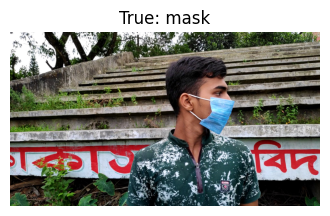

Predicted (Top-1): mask  conf=0.8374

Top predictions:
mask  conf=0.8374
improper_mouth  conf=0.1595
improper_chin  conf=0.0021

Sample file: /content/mask_dataset/mask/vlcsnap-2026-01-24-14h25m43s528.png


In [24]:
# ---------- 9) Display a random TEST image + predict (Top-1 + Top-3) ----------
test_samples = [base_ds.samples[i] for i in test_idx]
img_path, true_label = random.choice(test_samples)

img = Image.open(img_path).convert("RGB")
plt.figure(figsize=(4,4))
plt.imshow(img)
plt.axis("off")
plt.title(f"True: {class_names[true_label]}")
plt.show()

x = eval_tfms(img).unsqueeze(0).to(device)
with torch.no_grad():
    logits = model(x)
    probs = torch.softmax(logits, dim=1).squeeze(0)

top1_idx = int(torch.argmax(probs).item())
top1_conf = float(probs[top1_idx].item())
print(f"Predicted (Top-1): {class_names[top1_idx]}  conf={top1_conf:.4f}")

topk = 3
vals, inds = torch.topk(probs, k=min(topk, num_classes))
print("\nTop predictions:")
for v, i in zip(vals.tolist(), inds.tolist()):
    print(f"{class_names[i]}  conf={v:.4f}")

print("\nSample file:", img_path)

## Test using random uploaded image

In [28]:
from google.colab import files
uploaded = files.upload()

Saving 0.webp to 0 (1).webp


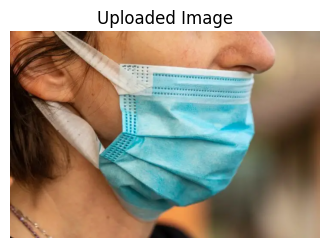

Predicted (Top-1): mask  conf=0.4788

Top predictions:
mask  conf=0.4788
no_mask  conf=0.3071
improper_mouth  conf=0.1484


In [29]:
img_path = list(uploaded.keys())[0]

# Load and show image
img = Image.open(img_path).convert("RGB")
plt.figure(figsize=(4,4))
plt.imshow(img)
plt.axis("off")
plt.title("Uploaded Image")
plt.show()

# Predict
model.eval()
x = eval_tfms(img).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(x)
    probs = torch.softmax(logits, dim=1).squeeze(0)

# Top-1
top1_idx = int(torch.argmax(probs).item())
top1_conf = float(probs[top1_idx].item())
print(f"Predicted (Top-1): {class_names[top1_idx]}  conf={top1_conf:.4f}")

# Top-3
topk = 3
vals, inds = torch.topk(probs, k=min(topk, len(class_names)))

print("\nTop predictions:")
for v, i in zip(vals.tolist(), inds.tolist()):
    print(f"{class_names[i]}  conf={v:.4f}")